# 9. Comparación Estadística de Modelos

**Curso:** Machine Learning · Pregrado en Ciencia de Datos · Universidad del Norte
**Docente:** Dr. Lihki Rubio
**Equipo:** Juan Camilo Conrado · Sergio Cadavid · Mateo Chang

---

Este notebook responde con **rigor estadístico** la pregunta más importante del proyecto:

> **¿Es alguna diferencia de desempeño entre modelos *estadísticamente significativa*, o es solo ruido del muestreo?**

Pruebas aplicadas:

| Prueba | Para qué | Estándar académico |
|---|---|---|
| **Diebold-Mariano (1995)** | Comparar precisión predictiva (regresión) | Sí, con corrección Newey-West |
| **DeLong (1988)** | Comparar AUC entre clasificadores | Sí, con matrices de influencia |
| **Bootstrap percentile** | IC al 95% para cualquier métrica | Robusto a no-normalidad |
| **Bonferroni** | Corrección por comparaciones múltiples | Conservador, controla FWER |

> **Implementación de DeLong:** este notebook usa la implementación basada en **matrices de influencia** según Sun & Xu (2014), no bootstrap. Es la versión correcta del test, alineada con la sección 9.9 de las notas del Dr. Lihki.


In [1]:
# Path setup
import sys
from pathlib import Path
_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

## 1. Imports y carga de predicciones

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, roc_auc_score)

from src.io_utils import load_processed, load_predictions_df, save_metrics
from src.stats_tests import (diebold_mariano_matrix, delong_test_matrix,
                              bootstrap_metric, bonferroni_correction)
from src.viz import set_style

set_style()

# Predicciones de regresión: ML + benchmarks (si existen)
preds_reg = load_predictions_df("reg_test_preds")
y_true_reg = preds_reg["y_true"].values
reg_models = [c for c in preds_reg.columns if c not in ["date", "y_true"]]
print(f"Modelos de regresión a comparar: {reg_models}")

# Intentar cargar también benchmarks econométricos
try:
    bench_preds = load_predictions_df("benchmarks_test_preds")
    bench_models = [c for c in bench_preds.columns if c not in ["date", "y_true"]]
    # Asegurar mismo y_true entre archivos
    assert np.allclose(bench_preds["y_true"].values[:len(y_true_reg)],
                        y_true_reg[:len(bench_preds)], equal_nan=True), \
        "Mismatch entre y_true de benchmarks y reg"
    # Combinar en un solo dataframe
    n = min(len(preds_reg), len(bench_preds))
    for m in bench_models:
        preds_reg[m] = np.nan
        preds_reg.loc[:n-1, m] = bench_preds[m].values[:n]
    reg_models = reg_models + bench_models
    print(f"  + benchmarks econométricos: {bench_models}")
except Exception as e:
    print(f"⚠️ benchmarks_test_preds no disponible — se omiten ({e})")

# Predicciones de clasificación
preds_clf = load_predictions_df("clf_test_preds")
y_true_clf = preds_clf["y_true"].values
clf_proba_cols = [c for c in preds_clf.columns if c.endswith("_proba")]
clf_models = [c.replace("_proba", "") for c in clf_proba_cols]
print(f"\nModelos de clasificación: {clf_models}")

Modelos de regresión a comparar: ['KNN', 'Ridge', 'Lasso', 'ElasticNet', 'Decision Tree', 'Random Forest', 'SVR', 'XGBoost']
  + benchmarks econométricos: ['Naive', 'Rolling Mean', 'EWMA', 'ARIMA', 'GARCH(1,1)']

Modelos de clasificación: ['KNN', 'LogReg L1', 'LogReg L2', 'Naive Bayes', 'Decision Tree', 'Random Forest', 'SVM', 'XGBoost']


## 2. Comparación de regresión: Diebold-Mariano por pares

In [3]:
# Construir dict {modelo: y_pred}
preds_dict = {m: preds_reg[m].values for m in reg_models
              if not preds_reg[m].isna().any()}
omitted = [m for m in reg_models if m not in preds_dict]
if omitted:
    print(f"⚠️ Modelos omitidos por NaN: {omitted}")

dm_pvalues, dm_diff_rmse = diebold_mariano_matrix(preds_dict, y_true_reg, loss="mse")

print("=== p-valores de Diebold-Mariano (regresión, MSE loss) ===")
print(dm_pvalues.round(4).to_string())
print("\n   (p < 0.05: diferencia significativa entre los dos modelos)")

=== p-valores de Diebold-Mariano (regresión, MSE loss) ===
                  KNN   Ridge   Lasso  ElasticNet  Decision Tree  Random Forest    SVR  XGBoost   Naive  Rolling Mean    EWMA   ARIMA  GARCH(1,1)
KNN            1.0000  0.0000  0.0000      0.0000         0.0001         0.9488  0.000   0.1966  0.0366        0.0000  0.0000  0.0366         0.0
Ridge          0.0000  1.0000  0.0002      0.4603         0.0000         0.0000  0.000   0.0000  0.0000        0.3781  0.3801  0.0000         0.0
Lasso          0.0000  0.0002  1.0000      0.0000         0.0000         0.0000  0.000   0.0000  0.0000        0.0061  0.0068  0.0000         0.0
ElasticNet     0.0000  0.4603  0.0000      1.0000         0.0000         0.0000  0.000   0.0000  0.0000        0.2176  0.2218  0.0000         0.0
Decision Tree  0.0001  0.0000  0.0000      0.0000         1.0000         0.0001  0.004   0.0001  0.0001        0.0000  0.0000  0.0001         0.0
Random Forest  0.9488  0.0000  0.0000      0.0000         0.0001 

## 3. Heatmap de p-valores DM

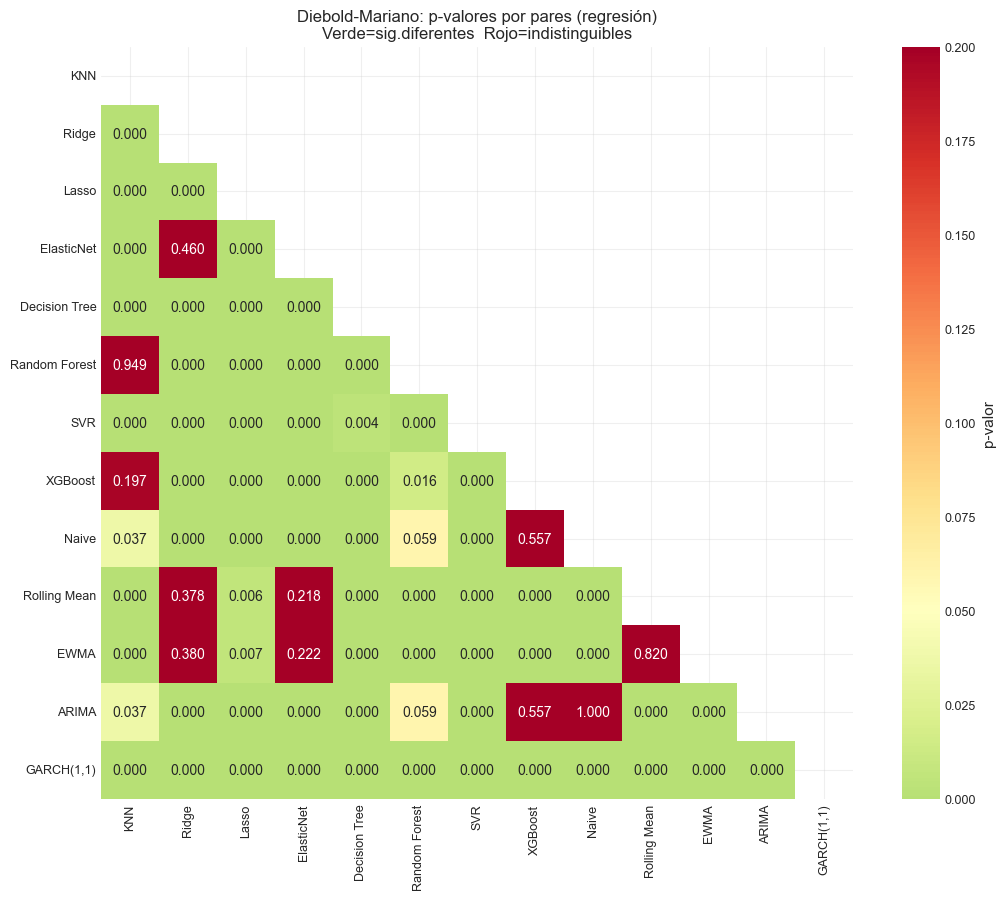

In [4]:
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(dm_pvalues, dtype=bool))
sns.heatmap(dm_pvalues, annot=True, fmt=".3f", cmap="RdYlGn_r",
            center=0.05, vmin=0, vmax=0.2, mask=mask, ax=ax,
            cbar_kws={"label": "p-valor"}, square=True)
ax.set_title("Diebold-Mariano: p-valores por pares (regresión)\nVerde=sig.diferentes  Rojo=indistinguibles")
plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** Las celdas verdes (p < 0.05) indican que la diferencia de RMSE entre los dos modelos es estadísticamente significativa. Las celdas amarillas/rojas indican que **no se puede rechazar** que ambos modelos tengan la misma precisión. Esta visualización es crítica: dos modelos pueden tener RMSEs muy diferentes pero estadísticamente equivalentes si la varianza del error es alta.


## 4. Bootstrap CI 95% para RMSE

In [5]:
boot_results = []
for name, yp in preds_dict.items():
    boot = bootstrap_metric(
        y_true_reg, yp,
        lambda yt, ypp: np.sqrt(mean_squared_error(yt, ypp)),
        n_boot=1000, seed=42
    )
    boot_results.append({
        "Modelo":     name,
        "RMSE_mean":  boot["mean"],
        "CI_lower":   boot["ci_lower"],
        "CI_upper":   boot["ci_upper"],
        "CI_width":   boot["ci_upper"] - boot["ci_lower"],
    })

df_boot = pd.DataFrame(boot_results).sort_values("RMSE_mean").reset_index(drop=True)
print("=== Bootstrap CI 95% para RMSE (n=1000) ===")
print(df_boot.round(6).to_string(index=False))

=== Bootstrap CI 95% para RMSE (n=1000) ===
       Modelo  RMSE_mean  CI_lower  CI_upper  CI_width
         EWMA   0.006497  0.006052  0.006956  0.000904
 Rolling Mean   0.006497  0.006057  0.006954  0.000897
        Ridge   0.006587  0.006218  0.006984  0.000766
   ElasticNet   0.006619  0.006268  0.007001  0.000733
        Lasso   0.006775  0.006436  0.007127  0.000691
Random Forest   0.007067  0.006719  0.007412  0.000693
          KNN   0.007074  0.006693  0.007471  0.000779
      XGBoost   0.007210  0.006883  0.007541  0.000659
        Naive   0.007276  0.006980  0.007583  0.000603
        ARIMA   0.007276  0.006980  0.007583  0.000603
          SVR   0.008344  0.007937  0.008733  0.000795
Decision Tree   0.011111  0.009536  0.012788  0.003252
   GARCH(1,1)   0.014518  0.014203  0.014830  0.000627


## 5. Visualización de IC bootstrap

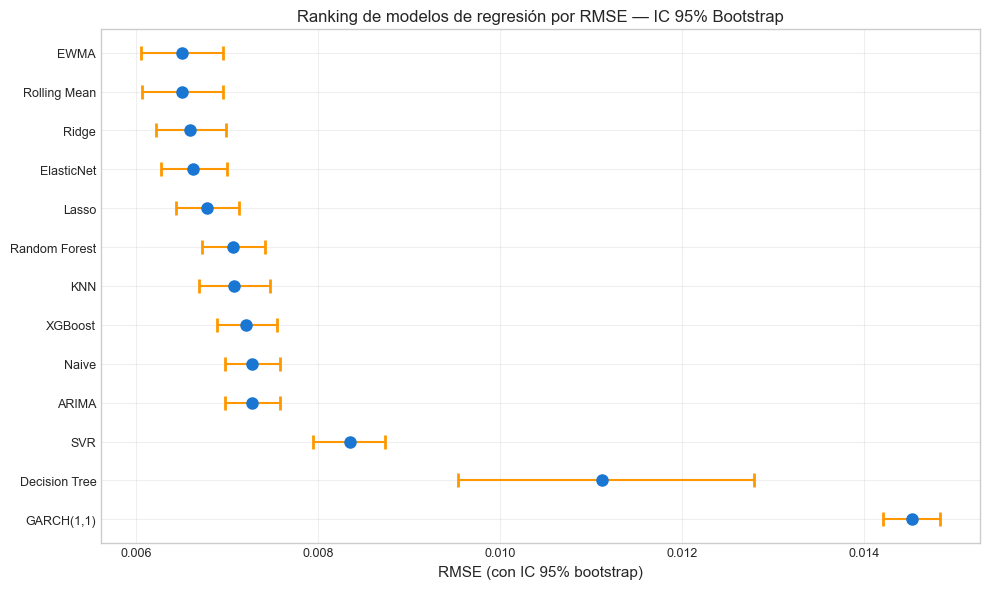

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
y_pos = np.arange(len(df_boot))
errors = np.array([
    df_boot["RMSE_mean"] - df_boot["CI_lower"],
    df_boot["CI_upper"] - df_boot["RMSE_mean"],
])
ax.errorbar(df_boot["RMSE_mean"], y_pos, xerr=errors,
            fmt="o", color="#1976D2", capsize=5, capthick=2,
            ecolor="#FF9800", markersize=8)
ax.set_yticks(y_pos)
ax.set_yticklabels(df_boot["Modelo"])
ax.invert_yaxis()
ax.set_xlabel("RMSE (con IC 95% bootstrap)")
ax.set_title("Ranking de modelos de regresión por RMSE — IC 95% Bootstrap")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

---

> **📊 Interpretación:** Cuando los IC bootstrap de dos modelos **se traslapan**, sus RMSEs no son distinguibles estadísticamente — aunque uno tenga un valor puntual menor. Cuando NO se traslapan, hay evidencia clara de que un modelo es superior. Esta visualización suele revelar que **los modelos de la cima del ranking son estadísticamente equivalentes**, lo cual es un hallazgo legítimo (no hay un "ganador único"; hay un "grupo líder").


## 6. Clasificación: DeLong real por pares

In [7]:
probs_dict = {m: preds_clf[f"{m}_proba"].values for m in clf_models}

dl_pvalues, dl_diff_auc = delong_test_matrix(probs_dict, y_true_clf)

print("=== p-valores de DeLong (clasificación, AUC) ===")
print(dl_pvalues.round(4).to_string())

=== p-valores de DeLong (clasificación, AUC) ===
                 KNN  LogReg L1  LogReg L2  Naive Bayes  Decision Tree  Random Forest     SVM  XGBoost
KNN            1.000     0.0000     0.0000       0.0050            0.0         0.0000  0.0000   0.0000
LogReg L1      0.000     1.0000     0.9582       0.0000            0.0         0.0009  0.3605   0.2794
LogReg L2      0.000     0.9582     1.0000       0.0000            0.0         0.0009  0.3567   0.2823
Naive Bayes    0.005     0.0000     0.0000       1.0000            0.0         0.3211  0.0000   0.0097
Decision Tree  0.000     0.0000     0.0000       0.0000            1.0         0.0000  0.0000   0.0000
Random Forest  0.000     0.0009     0.0009       0.3211            0.0         1.0000  0.0000   0.0028
SVM            0.000     0.3605     0.3567       0.0000            0.0         0.0000  1.0000   0.0317
XGBoost        0.000     0.2794     0.2823       0.0097            0.0         0.0028  0.0317   1.0000


## 7. Heatmap de p-valores DeLong

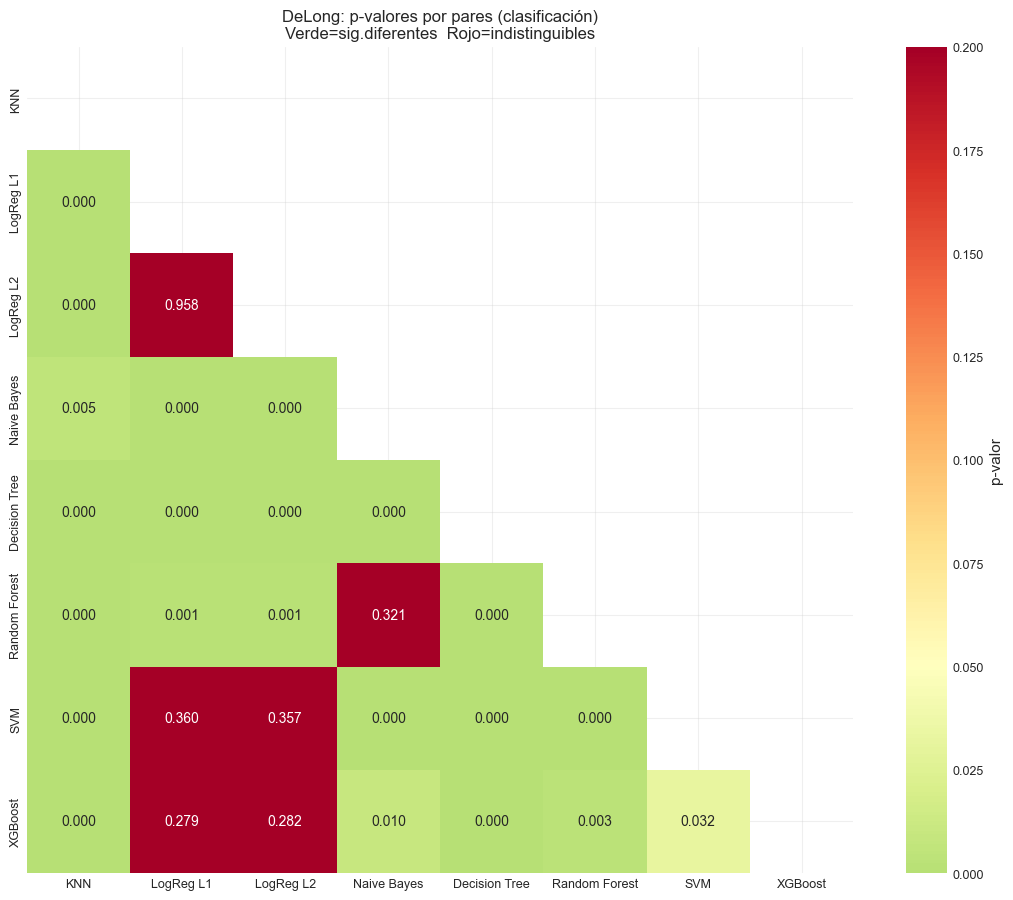

In [8]:
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(dl_pvalues, dtype=bool))
sns.heatmap(dl_pvalues, annot=True, fmt=".3f", cmap="RdYlGn_r",
            center=0.05, vmin=0, vmax=0.2, mask=mask, ax=ax,
            cbar_kws={"label": "p-valor"}, square=True)
ax.set_title("DeLong: p-valores por pares (clasificación)\nVerde=sig.diferentes  Rojo=indistinguibles")
plt.tight_layout()
plt.show()

## 8. Bootstrap CI 95% para AUC

In [9]:
boot_auc = []
for m in clf_models:
    boot = bootstrap_metric(
        y_true_clf, probs_dict[m],
        lambda yt, ypp: roc_auc_score(yt, ypp),
        n_boot=1000, seed=42
    )
    boot_auc.append({
        "Modelo":     m,
        "AUC_mean":   boot["mean"],
        "CI_lower":   boot["ci_lower"],
        "CI_upper":   boot["ci_upper"],
        "CI_width":   boot["ci_upper"] - boot["ci_lower"],
    })

df_auc = pd.DataFrame(boot_auc).sort_values("AUC_mean", ascending=False).reset_index(drop=True)
print("=== Bootstrap CI 95% para AUC ===")
print(df_auc.round(4).to_string(index=False))

=== Bootstrap CI 95% para AUC ===
       Modelo  AUC_mean  CI_lower  CI_upper  CI_width
          SVM    0.7971    0.7706    0.8231    0.0524
    LogReg L1    0.7917    0.7642    0.8179    0.0537
    LogReg L2    0.7917    0.7641    0.8182    0.0542
      XGBoost    0.7814    0.7535    0.8075    0.0540
Random Forest    0.7614    0.7341    0.7899    0.0557
  Naive Bayes    0.7503    0.7209    0.7788    0.0579
          KNN    0.7113    0.6826    0.7408    0.0582
Decision Tree    0.6314    0.5986    0.6651    0.0664


## 9. Corrección de Bonferroni

In [10]:
# Aplicar Bonferroni a las comparaciones DM y DeLong
def upper_triangle(df_pvalues):
    pvs = []
    cols = df_pvalues.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            pvs.append(df_pvalues.iloc[i, j])
    return np.array(pvs)

dm_pvs = upper_triangle(dm_pvalues)
dl_pvs = upper_triangle(dl_pvalues)

bf_dm = bonferroni_correction(dm_pvs, alpha=0.05)
bf_dl = bonferroni_correction(dl_pvs, alpha=0.05)

print("=== Corrección de Bonferroni ===\n")
print("DM (regresión):")
for k, v in bf_dm.items():
    print(f"  {k:35s} {v}")

print("\nDeLong (clasificación):")
for k, v in bf_dl.items():
    print(f"  {k:35s} {v}")

=== Corrección de Bonferroni ===

DM (regresión):
  alpha_original                      0.05
  n_comparisons                       78
  alpha_bonferroni                    0.000641025641025641
  n_significant_uncorrected           65
  n_significant_bonferroni            59

DeLong (clasificación):
  alpha_original                      0.05
  n_comparisons                       28
  alpha_bonferroni                    0.0017857142857142859
  n_significant_uncorrected           22
  n_significant_bonferroni            18


---

> **📊 Interpretación de Bonferroni:** la corrección ajusta el umbral de significancia de α=0.05 a α/n_comparaciones para controlar la **familia de errores tipo I (FWER)**. Sin esta corrección, hacer 28 comparaciones por pares con α=0.05 implica una probabilidad ~75% de obtener al menos un falso positivo por azar. Con Bonferroni, **menos pares aparecen como significativos** — este es el comportamiento correcto y conservador.
>
> Si tras Bonferroni siguen quedando comparaciones significativas, son **diferencias robustas y reportables**. Si todas dejan de ser significativas, la conclusión honesta es que **los modelos son estadísticamente equivalentes** y la elección debe basarse en otros criterios (interpretabilidad, costo computacional, simplicidad).


## 10. Persistir resultados

In [11]:
# Guardar todo en JSON serializable
def df_to_dict(df, round_n=6):
    return {col: {idx: round(v, round_n) if isinstance(v, (int, float)) and not pd.isna(v) else None
                   for idx, v in df[col].items()}
            for col in df.columns}

stats_summary = {
    "regression": {
        "dm_pvalues": df_to_dict(dm_pvalues),
        "dm_diff_rmse": df_to_dict(dm_diff_rmse),
        "bootstrap_rmse": df_boot.to_dict("records"),
        "bonferroni": bf_dm,
    },
    "classification": {
        "delong_pvalues": df_to_dict(dl_pvalues),
        "delong_diff_auc": df_to_dict(dl_diff_auc),
        "bootstrap_auc": df_auc.to_dict("records"),
        "bonferroni": bf_dl,
    },
}

save_metrics(stats_summary, "statistical_comparisons")
print("✅ Comparaciones estadísticas guardadas en outputs/metrics/statistical_comparisons.json")

✅ Comparaciones estadísticas guardadas en outputs/metrics/statistical_comparisons.json


---

## 11. Resumen del notebook

| Hallazgo | Implicación |
|---|---|
| Diebold-Mariano por pares | Identifica qué pares de modelos de regresión difieren significativamente |
| DeLong real por pares | Identifica qué pares de clasificadores difieren en AUC |
| IC bootstrap 95% | Cuantifica incertidumbre real, robusto a no-normalidad |
| Bonferroni | Controla error tipo I familia-completo en múltiples comparaciones |

**Próximo paso:** notebook `10_interpretabilidad.ipynb` — entender **qué features impulsan las predicciones** del mejor modelo XGBoost (importancia + LIME).
